In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t20_data = pd.read_csv('archive/ball_by_ball_it20.csv')


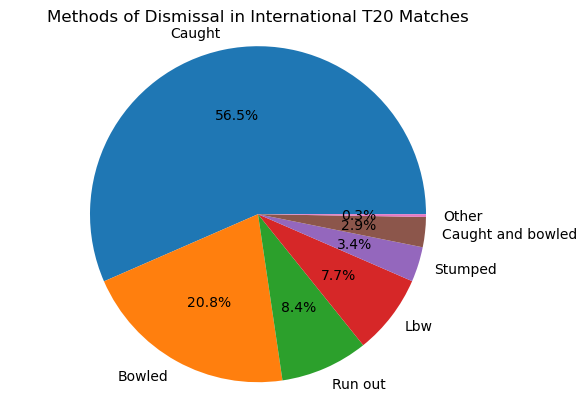

In [2]:
# Filter data frame to get rid of N/A values in the method column
filtered_df = t20_data[t20_data['Method'] != 'N/A']

# Count values in filtered data frame
value_counts = filtered_df['Method'].value_counts()

threshold = 50  # Set the minimum occurrence count for displaying a slice

# Filter out the methods with occurrence count below the threshold
filtered_value_counts = value_counts[value_counts >= threshold]

# Create a custom "Other" category to group rare methods below the threshold
other_count = value_counts[value_counts < threshold].sum()
filtered_value_counts['other'] = other_count

# Capitalize the first letter of each label using str.capitalize()
labels = filtered_value_counts.index.str.capitalize()

# Plot the pie chart with the filtered value counts
plt.pie(filtered_value_counts, labels=labels, autopct='%.1f%%')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Methods of Dismissal in International T20 Matches')
plt.show()

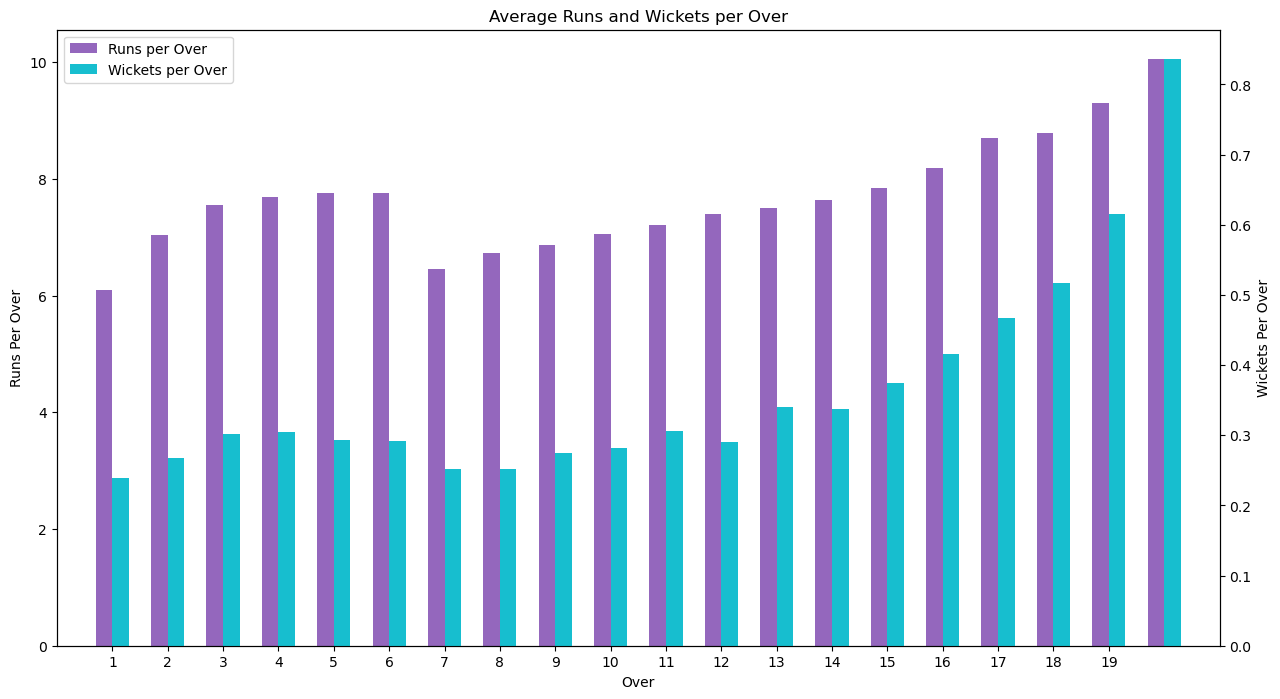

In [3]:
overs = list(np.arange(1,21))
Rpo = []
Wpo = []
for over in overs:
    over_df = t20_data.loc[t20_data['Over'] == over]   
    total_balls = len(over_df[over_df['Ball Rebowled'] == 0].index)
    avg_wick_pb = over_df['Wicket'].sum()/(total_balls)
    avg_pb = over_df['Runs From Ball'].sum()/(total_balls)
    Wpo.append(avg_wick_pb*6)
    Rpo.append(avg_pb*6)


# Create a figure and axis object
fig , ax = plt.subplots(figsize=(15, 8))

# Set the x-axis label
ax.set_xlabel('Over')

# Set the y-axis label for the first field
ax.set_ylabel('Runs Per Over', color='k')
# Create the bar chart for the first field
ax.bar(np.array(overs) - 0.15, Rpo, color='tab:purple', label='Runs per Over', width=0.3)

# Create a second y-axis object
ax2 = ax.twinx()

# Set the y-axis label for the second field
ax2.set_ylabel('Wickets Per Over', color='k')

# Create the bar chart for the second field
ax2.bar(np.array(overs) + 0.15, Wpo, color='tab:cyan',label = 'Wickets per Over', width=0.3)

# Set the x-axis limits to ensure all bars are visible
ax.set_xlim([0, 21])
# create the legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
plt.xticks(np.arange(1, 20, step=1))
# Show the plot
plt.title('Average Runs and Wickets per Over')
plt.show()

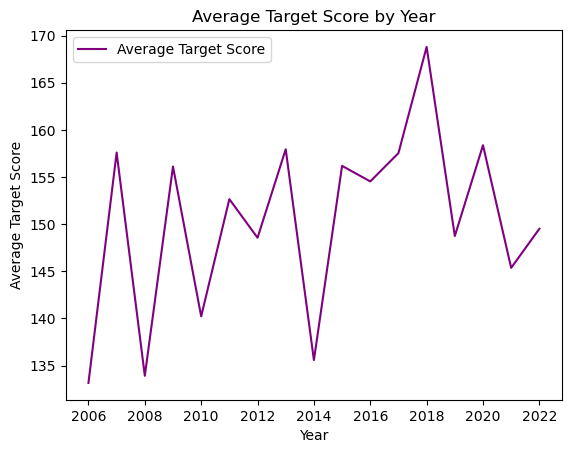

In [4]:
years = ['2006', '2007', '2008', '2009','2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
year_targets = []
for year in years:
    targets = []
    year_df = t20_data[t20_data['Date'].str.slice(stop=4) == year]
    
    for j in range(len(year_df.index)-1):
        if year_df['Match ID'].iloc[j] != year_df['Match ID'].iloc[j+1]:
            targets.append(year_df['Target Score'].iloc[j])
    
    year_targets.append(sum(targets)/len(targets))

df = pd.DataFrame({'Average Target Score': year_targets}, index=years)
# Plot the data against years

df.plot(kind='line', color='purple')

# Set the title and axis labels
plt.title('Average Target Score by Year')
plt.xlabel('Year')
plt.ylabel('Average Target Score')
plt.show()

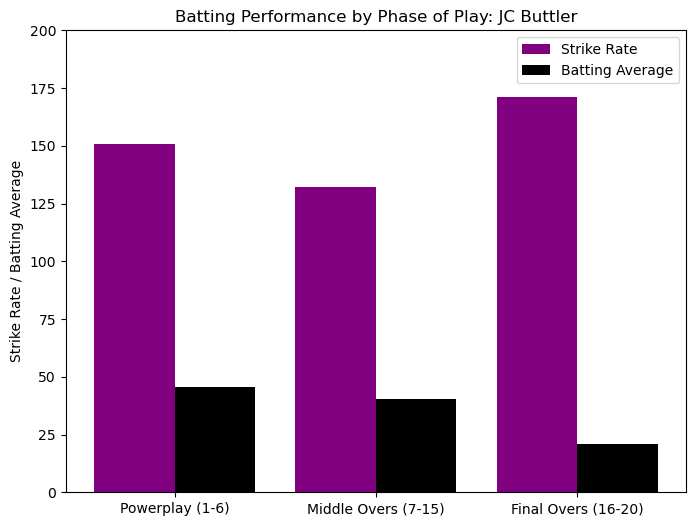

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

powerplay_df = t20_data.loc[(t20_data['Over'] >= 1) & (t20_data['Over'] <= 6)]
middle_df = t20_data.loc[(t20_data['Over'] >= 7) & (t20_data['Over'] <= 15)]
end_df = t20_data.loc[(t20_data['Over'] >= 16) & (t20_data['Over'] <= 20)]

player = 'JC Buttler'
dfs =[powerplay_df, middle_df, end_df]
AVGs = []
SRs = []
BASRAs = []
for df in dfs:
    player_mask = (df['Batter'] == player)
    batter_df = df.loc[player_mask]
    n_outs = len(df[df['Player Out'] == player].index)
    total_runs = sum(batter_df['Batter Runs'])
    total_bf = len(batter_df[batter_df['Ball Rebowled'] == 0].index)
    bat_avg = total_runs/n_outs
    sr = (total_runs/total_bf)*100
    basra = bat_avg + sr
    AVGs.append(bat_avg)
    SRs.append(sr)
    BASRAs.append(basra)


# Example data
stages = ['Powerplay (1-6)', 'Middle Overs (7-15)', 'Final Overs (16-20)']

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Set the x-axis labels and positions
x_labels = stages
x_positions = np.arange(len(x_labels))

ax.bar(x_positions, SRs, width=0.4, label='Strike Rate', color='purple')

# Plot the batting average bars

ax.bar(x_positions+0.4, AVGs, width=0.4, label='Batting Average', color = 'black')

# Set the y-axis limits and labels
ax.set_ylim([0, 200])
ax.set_ylabel('Strike Rate / Batting Average')

# Set the title and legend
ax.set_title('Batting Performance by Phase of Play: JC Buttler')
ax.legend()

# Add the x-axis labels and tick marks
ax.set_xticks(x_positions+0.2)
ax.set_xticklabels(x_labels)

plt.show()

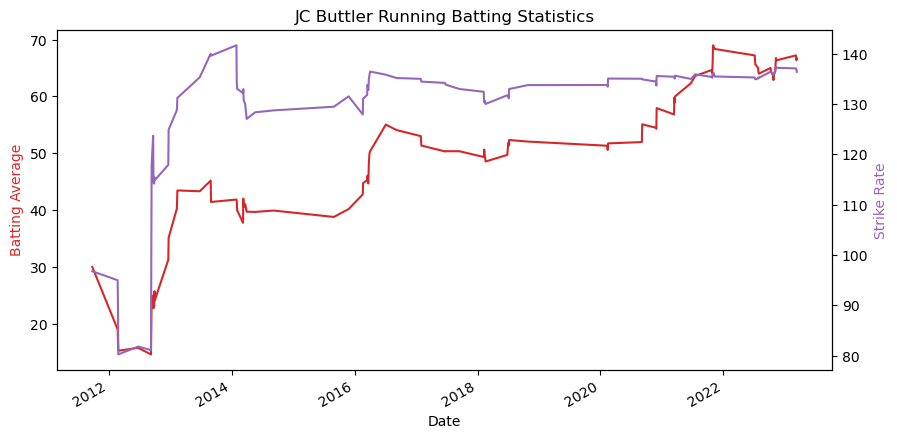

In [6]:
player = 'JC Buttler'

# Build a per-match summary for the player and compute running (cumulative) averages
player_mask = (t20_data['Batter'] == player) | (t20_data['Non Striker'] == player)
player_df = t20_data[player_mask].copy()
player_df['Date'] = pd.to_datetime(player_df['Date'])

# Aggregate per match-date: total runs, valid balls, and whether player was out
per_game = player_df.groupby('Date').agg(
    runs=('Batter Runs', 'sum'),
    valid_balls=('Ball Rebowled', lambda x: (x != 1).sum()),
    was_out=('Player Out', lambda s: player in s.values)
)
per_game = per_game.sort_index()

# Cumulative statistics up to each date
per_game['cum_runs'] = per_game['runs'].cumsum()
per_game['cum_valid_balls'] = per_game['valid_balls'].cumsum()
per_game['cum_outs'] = per_game['was_out'].cumsum()

# Avoid division by zero when computing averages
per_game['batting_avg'] = per_game['cum_runs'] / per_game['cum_outs'].replace(0, pd.NA)
per_game['strike_rate'] = (per_game['cum_runs'] / per_game['cum_valid_balls']) * 100

# Plot the cumulative batting average and strike rate
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(per_game.index, per_game['batting_avg'], color='tab:red', label='Batting Average')
ax2 = ax1.twinx()
ax2.plot(per_game.index, per_game['strike_rate'], color='tab:purple', label='Strike Rate')
ax1.set_xlabel('Date')
ax1.set_ylabel('Batting Average', color='tab:red')
ax2.set_ylabel('Strike Rate', color='tab:purple')
fig.autofmt_xdate()
plt.title(f'{player} Running Batting Statistics')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2532\2147424429.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  middle_df['Date'] = pd.to_datetime(middle_df['Date'])


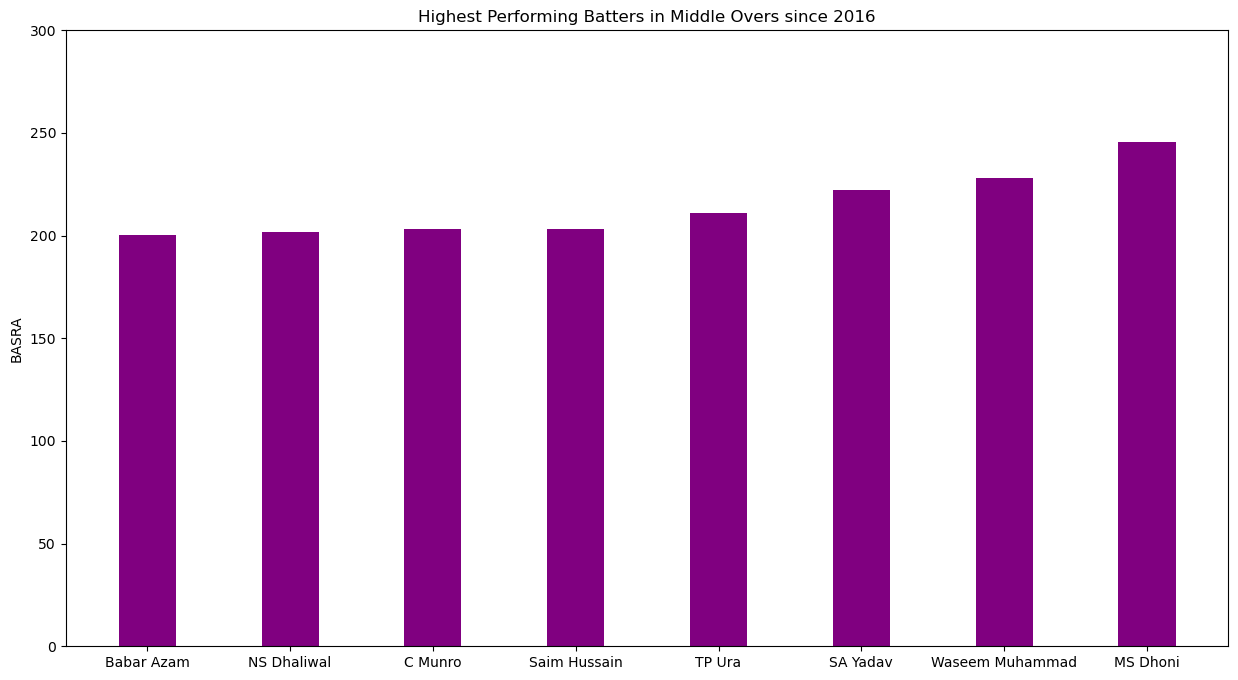

In [7]:
# Convert the "date" column to datetime format
middle_df['Date'] = pd.to_datetime(middle_df['Date'])

# Slice the dataframe by values in the "date" column after the year 2015
middle_df = middle_df[middle_df['Date'].dt.year > 2015]




# Get list of batters that have been at the crease during the middle overs in this period
batter_list = middle_df['Batter'].unique().tolist()
BATTER = []
BASRA = []
BASRA2 = []
for batter in batter_list:
    batter_df = middle_df.loc[middle_df['Batter'] == batter]
    
    if len(batter_df.index) > 200:
        BATTER.append(batter)
        n_outs = len(middle_df[middle_df['Player Out'] == batter].index)
        
        
        total_runs = sum(batter_df['Batter Runs'])
        total_bf = len(batter_df[batter_df['Ball Rebowled'] == 0].index)
        bat_avg = total_runs/n_outs
        sr = (total_runs/total_bf)*100
        BASRA.append(bat_avg + sr)
        BASRA2.append(2*bat_avg + sr)

# convert the list to a numpy array
BASRA = np.array(BASRA)

# get the indices of the 8 max values
max_indices = np.argsort(BASRA)[-8:]
max_batters = [BATTER[i]for i in max_indices]
max_BASRAs = [BASRA[i] for i in max_indices]

fig, ax = plt.subplots(figsize=(15, 8))

x_labels = max_batters
x_positions = np.arange(len(x_labels))

ax.bar(x_positions, max_BASRAs, width=0.4, label='BASRA', color='purple')

# Set the y-axis limits and labels
ax.set_ylim([0, 300])
ax.set_ylabel('BASRA')

# Add the x-axis labels and tick marks
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set the title and legend
ax.set_title('Highest Performing Batters in Middle Overs since 2016')


plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2532\3301488433.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  starts['Valid Ball'] = (starts['Ball Rebowled'] != 1).astype(int)


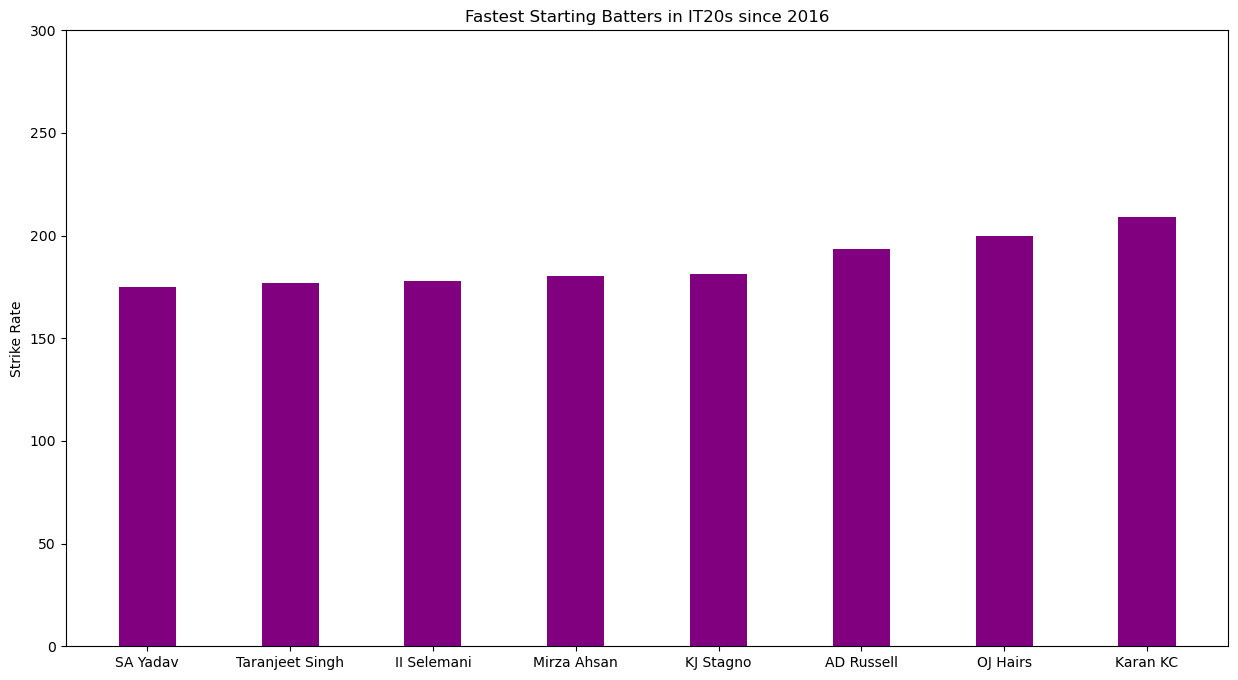

In [8]:
t20_data['Date'] = pd.to_datetime(t20_data['Date'])
starts = t20_data[t20_data['Date'].dt.year > 2015]
starts['Valid Ball'] = (starts['Ball Rebowled'] != 1).astype(int)
batter_list = starts['Batter'].unique().tolist()
SRs = []
batters = []
for batter in batter_list:
    
    batter_df = starts.loc[starts['Batter'] == batter]
    ids = batter_df['Match ID'].unique()
    first10 = []
    for match_id in ids:
        game_df = batter_df[batter_df['Match ID'] == match_id]
        cum_sum = 0
        index_to_stop = 0
        for index, row in game_df.iterrows():
            cum_sum += row['Valid Ball']
            if cum_sum >= 10:
                index_to_stop = index + 1
                break
        game_df = game_df.iloc[:index_to_stop]
        first10.append(game_df)
    first10 = pd.concat(first10, axis=0)
    if len(first10.index) > 100:
        batters.append(batter)
        SRs.append((first10['Batter Runs'].sum()/len(first10[first10['Ball Rebowled'] == 0].index))*100)

# convert the list to a numpy array
SRs = np.array(SRs)

# get the indices of the 8 max values
max_indices = np.argsort(SRs)[-8:]
max_batters = [batters[i]for i in max_indices]
max_SRs = [SRs[i] for i in max_indices]

fig, ax = plt.subplots(figsize=(15, 8))

x_labels = max_batters
x_positions = np.arange(len(x_labels))

ax.bar(x_positions, max_SRs, width=0.4, label='First 10 Balls of Innings Strike Rate', color='purple')

# Set the y-axis limits and labels
ax.set_ylim([0, 300])
ax.set_ylabel('Strike Rate')
#Add the x-axis labels and tick marks
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set the title and legend
ax.set_title('Fastest Starting Batters in IT20s since 2016')


plt.show()

In [9]:
import pandas as pd

df = t20_data.copy()

# Step 0: Create a 'valid_ball' column
df['Valid Ball'] = (df['Ball Rebowled'] != 1).astype(int)

# Step 1: Group by Batter and calculate the total runs and valid balls faced
grouped_runs_balls = df.groupby('Batter').agg(
    total_runs=('Batter Runs', 'sum'),
    balls_faced=('Valid Ball', 'sum'),
    innings=('Match ID', 'nunique')
)

# Step 2: Count the number of times each batter is out
outs = df.groupby('Player Out').size().reset_index(name='num_outs')
outs.rename(columns={'Player Out': 'Batter'}, inplace=True)

# Step 3: Merge the two dataframes on 'Batter'
merged = pd.merge(grouped_runs_balls, outs, on='Batter', how='left').fillna(0)

# Step 4: Calculate the batting average and strike rate
merged['batting_avg'] = merged['total_runs'] / merged['num_outs'].replace(0, 1)  # handle potential division by zero
merged['strike_rate'] = (merged['total_runs'] / merged['balls_faced']) * 100

def get_batter_countries(row):
    countries = []
    if row['Innings'] == 1:
        team = row['Bat First']
    else:
        team = row['Bat Second']
    
    return team

# Apply the get_batter_countries function to each row
df['Batter Countries'] = df.apply(get_batter_countries, axis=1)

# Step 6: Merge the bowler's country information into the merged DataFrame
batter_countries = df.groupby('Batter')['Batter Countries'].unique().apply("/".join)
batter_data = pd.merge(batter_countries, merged, on='Batter', how='left')
batter_data['bf_pw'] = batter_data['balls_faced']/batter_data['num_outs']
batter_data['bf_pi'] = batter_data['balls_faced']/batter_data['innings']


# Handle NaN values (possible division by zero scenarios)
batter_data.fillna(0, inplace=True)


# Reset index to have Batter as a column
result_df = batter_data.reset_index()[['Batter', 'Batter Countries', 'innings', 'total_runs', 'balls_faced', 'num_outs', 'batting_avg', 'strike_rate', 'bf_pi', 'bf_pw']]
result_df.rename(columns={'Batter Countries':'Country'}, inplace=True)
result_df.to_csv('archive/batting_stats_T20I.csv')

In [10]:
import pandas as pd

df = t20_data.copy()

# Step -1: Create a 'valid_ball' column
df.loc[:, 'Valid Ball'] = (df['Ball Rebowled'] != 1).astype(int)

# Step 0: Filter rows where Method suggests the bowler took a wicket
relevant_methods = ["bowled", "caught", "lbw", "stumped", "hit wicket", "caught & bowled"]
wickets_df = df[df['Method'].isin(relevant_methods)]

# Step 1: Group by Bowler to aggregate runs given, balls bowled, and wickets taken
bowler_data = df.groupby('Bowler').agg(
    runs_conceded=('Bowler Runs Conceded', 'sum'),
    balls_bowled=('Valid Ball', 'sum')
)
bowler_data['wickets'] = wickets_df.groupby('Bowler').size()

# Step 2: Calculate bowling average and economy
bowler_data['bowling_avg'] = bowler_data['runs_conceded'] / bowler_data['wickets']
bowler_data['economy'] = bowler_data['runs_conceded'] / (bowler_data['balls_bowled'] / 6)  # convert balls to overs
bowler_data['strike_rate'] = bowler_data['balls_bowled'] / bowler_data['wickets']

matches_bowled = df.groupby('Bowler')['Match ID'].nunique()
bowler_data['matches_bowled'] = matches_bowled


# Step 5: Determine the bowler's countries based on innings and team names
def get_bowler_countries(row):
    countries = []
    if row['Innings'] == 1:
        team = row['Bat Second']
    else:
        team = row['Bat First']
    
    return team

# Apply the get_bowler_countries function to each row
df['Bowler Countries'] = df.apply(get_bowler_countries, axis=1)
# Step 6: Merge the bowler's country information into the bowler_data DataFrame
bowler_countries = df.groupby('Bowler')['Bowler Countries'].unique().apply("/".join)

bowler_data['Country'] = bowler_countries

bowler_data['balls_bowled_pm'] = bowler_data['balls_bowled']/bowler_data['matches_bowled']
bowler_data['wickets_pm'] = bowler_data['wickets']/bowler_data['matches_bowled']

# Handle NaN values (possible division by zero scenarios)
bowler_data.fillna(0, inplace=True)

# Reset index to have Bowler as a column
bowler_result = bowler_data.reset_index()[['Bowler', 'Country', 'matches_bowled', 'wickets', 'balls_bowled','runs_conceded', 'bowling_avg', 'economy', 'strike_rate', 'balls_bowled_pm', 'wickets_pm']]

bowler_result.to_csv('archive/bowling_stats_T20I.csv')

In [11]:
# List of ICC member nations
icc_member_nations = [
    'Afghanistan', 'Australia', 'Bangladesh', 'England', 'India',
    'Ireland', 'New Zealand', 'Pakistan', 'South Africa', 'Sri Lanka',
    'West Indies', 'Zimbabwe'
]

# Filter rows where both teams are ICC member nations
member_data = t20_data[
    (t20_data['Bat First'].isin(icc_member_nations)) &
    (t20_data['Bat Second'].isin(icc_member_nations))
]

member_data.reset_index(drop=True, inplace=True)
# Consider games from 2015 onwards
df = member_data.copy()
df['Date'] = pd.to_datetime(df['Date'])
date = '2021-08-01'
date = pd.to_datetime(date)
df = df[df['Date'] > date]

# Step -1: Create a 'valid_ball' column
df['Valid Ball'] = (df['Ball Rebowled'] != 1).astype(int)

# Step 0: Filter rows where Method suggests the bowler took a wicket
relevant_methods = ["bowled", "caught", "lbw", "stumped", "hit wicket", "caught & bowled"]
wickets_df = df[df['Method'].isin(relevant_methods)]

# Step 1: Group by Bowler to aggregate runs given, balls bowled, and wickets taken
bowler_data = df.groupby('Bowler').agg(
    runs_conceded=('Bowler Runs Conceded', 'sum'),
    balls_bowled=('Valid Ball', 'sum')
)
bowler_data['wickets'] = wickets_df.groupby('Bowler').size()
# Step 2: Calculate bowling average and economy
bowler_data['bowling_avg'] = bowler_data['runs_conceded'] / bowler_data['wickets']
bowler_data['economy'] = bowler_data['runs_conceded'] / (bowler_data['balls_bowled'] / 6)  # convert balls to overs
bowler_data['bowling_strike_rate'] = bowler_data['balls_bowled'] / bowler_data['wickets']

matches_bowled = df.groupby('Bowler')['Match ID'].nunique()
bowler_data['matches_bowled'] = matches_bowled


# Step 5: Determine the bowler's countries based on innings and team names
def get_bowler_countries(row):
    countries = []
    if row['Innings'] == 1:
        team = row['Bat Second']
    else:
        team = row['Bat First']
    
    return team

# Apply the get_bowler_countries function to each row
df['Bowler Countries'] = df.apply(get_bowler_countries, axis=1)

# Step 6: Merge the bowler's country information into the bowler_data DataFrame
bowler_countries = df.groupby('Bowler')['Bowler Countries'].unique().apply("/".join)
bowler_data['Country'] = bowler_countries

bowler_data['balls_bowled_pm'] = bowler_data['balls_bowled']/bowler_data['matches_bowled']
bowler_data['wickets_pm'] = bowler_data['wickets']/bowler_data['matches_bowled']

# Handle NaN values (possible division by zero scenarios)
bowler_data.fillna(0, inplace=True)

# Reset index to have Bowler as a column
bowlers = bowler_data.reset_index()[['Bowler', 'Country', 'matches_bowled', 'wickets', 'balls_bowled','runs_conceded', 'bowling_avg', 'economy', 'bowling_strike_rate', 'balls_bowled_pm', 'wickets_pm']]

df = member_data.copy()
df['Date'] = pd.to_datetime(df['Date'])
date = '2021-08-01'
date = pd.to_datetime(date)
df = df[df['Date'] > date]

# Step 0: Create a 'valid_ball' column
df['Valid Ball'] = (df['Ball Rebowled'] != 1).astype(int)

# Step 1: Group by Batter and calculate the total runs and valid balls faced
grouped_runs_balls = df.groupby('Batter').agg(
    total_runs=('Batter Runs', 'sum'),
    balls_faced=('Valid Ball', 'sum'),
    innings=('Match ID', 'nunique')
)

# Step 2: Count the number of times each batter is out
outs = df.groupby('Player Out').size().reset_index(name='num_outs')
outs.rename(columns={'Player Out': 'Batter'}, inplace=True)

# Step 3: Merge the two dataframes on 'Batter'
merged = pd.merge(grouped_runs_balls, outs, on='Batter', how='left').fillna(0)
# Step 4: Calculate batting average and strike rate
merged['batting_avg'] = merged['total_runs'] / merged['num_outs'].replace(0, 1)  # handle potential division by zero
merged['strike_rate'] = (merged['total_runs'] / merged['balls_faced']) * 100

def get_batter_countries(row):
    countries = []
    if row['Innings'] == 1:
        team = row['Bat First']
    else:
        team = row['Bat Second']
    
    return team

# Apply the get_batter_countries function to each row
df['Batter Countries'] = df.apply(get_batter_countries, axis=1)

# Step 6: Merge the bowler's country information into the merged DataFrame
batter_countries = df.groupby('Batter')['Batter Countries'].unique().apply("/".join)
batter_data = pd.merge(batter_countries, merged, on='Batter', how='left')
# Handle NaN values (possible division by zero scenarios)
batter_data.fillna(0, inplace=True)
batter_data['bf_pw'] = batter_data['balls_faced']/batter_data['num_outs']
batter_data['bf_pi'] = batter_data['balls_faced']/batter_data['innings']


# Reset index to have Batter as a column
result_df = batter_data.reset_index()[['Batter', 'Batter Countries', 'innings', 'total_runs', 'balls_faced', 'num_outs', 'batting_avg', 'strike_rate', 'bf_pi', 'bf_pw']]
result_df.rename(columns={'Batter Countries':'Country'}, inplace=True)

batters = result_df

In [12]:
bowlers = bowlers[bowlers['matches_bowled'] > 5]
bowlers = bowlers[bowlers['wickets'] > 0]
bowlers.reset_index(drop=True, inplace=True)
batters = batters[batters['innings'] > 5]
batters.reset_index(drop=True, inplace=True)
batters

,Batter,Country,innings,total_runs,balls_faced,num_outs,batting_avg,strike_rate,bf_pi,bf_pw
0,A Balbirnie,Ireland,29,613,505,29.0,21.137931,121.386139,17.413793,17.413793
1,A Nortje,South Africa,6,6,16,4.0,1.500000,37.500000,2.666667,4.000000
2,A Zampa,Australia,6,8,18,4.0,2.000000,44.444444,3.000000,4.500000
3,AC Agar,Australia,9,99,110,8.0,12.375000,90.000000,12.222222,13.750000
4,AD Hales,England,14,430,292,13.0,33.076923,147.260274,20.857143,22.461538
...,...,...,...,...,...,...,...,...,...,...
183,WA Young,New Zealand,9,131,153,9.0,14.555556,85.620915,17.000000,17.000000
184,WD Parnell,South Africa,9,60,82,5.0,12.000000,73.170732,9.111111,16.400000
185,WIA Fernando,Sri Lanka,9,50,58,9.0,5.555556,86.206897,6.444444,6.444444
186,WP Masakadza,Zimbabwe,6,38,44,5.0,7.600000,86.363636,7.333333,8.800000


In [13]:
# Create a list of names common to both 'Batter' and 'Bowler' columns
common_names = list(set(batters['Batter']) & set(bowlers['Bowler']))

# Initialize an empty list to store merged DataFrames
merged_dfs = []

# Merge DataFrames for each common name along axis 1
for name in common_names:
    batter_subset = batters[batters['Batter'] == name].reset_index(drop=True)
    bowler_subset = bowlers[bowlers['Bowler'] == name].drop(['Bowler','Country'], axis=1).reset_index(drop=True)
    
    merged_subset = pd.concat([batter_subset, bowler_subset], axis=1)
    merged_dfs.append(merged_subset)

# Combine all merged DataFrames into a single DataFrame
all_rounders = pd.concat(merged_dfs, ignore_index=True, axis=0)
all_rounders['balls_bowled_pm'] = all_rounders['balls_bowled']/all_rounders['matches_bowled']
all_rounders = all_rounders[all_rounders['balls_faced'] > 100]
all_rounders = all_rounders[all_rounders['balls_bowled']> 100]
all_rounders

,Batter,Country,innings,total_runs,balls_faced,num_outs,batting_avg,strike_rate,bf_pi,bf_pw,matches_bowled,wickets,balls_bowled,runs_conceded,bowling_avg,economy,bowling_strike_rate,balls_bowled_pm,wickets_pm
1,JDS Neesham,New Zealand,25,300,195,16.0,18.750000,153.846154,7.800000,12.187500,18,10.0,254,389,38.900000,9.188976,25.400000,14.111111,0.555556
2,OF Smith,West Indies,18,182,122,11.0,16.545455,149.180328,6.777778,11.090909,22,22.0,372,641,29.136364,10.338710,16.909091,16.909091,1.000000
5,GH Dockrell,Ireland,27,429,313,17.0,25.235294,137.060703,11.592593,18.411765,11,5.0,150,182,36.400000,7.280000,30.000000,13.636364,0.454545
7,GJ Maxwell,Australia,21,356,289,18.0,19.777778,123.183391,13.761905,16.055556,17,8.0,199,240,30.000000,7.236181,24.875000,11.705882,0.470588
11,Mosaddek Hossain,Bangladesh,14,143,117,9.0,15.888889,122.222222,8.357143,13.000000,11,10.0,177,207,20.700000,7.016949,17.700000,16.090909,0.909091
14,MM Ali,England,29,639,426,21.0,30.428571,150.000000,14.689655,20.285714,25,20.0,342,461,23.050000,8.087719,17.100000,13.680000,0.800000
15,MD Shanaka,Sri Lanka,33,712,526,24.0,29.666667,135.361217,15.939394,21.916667,18,8.0,149,239,29.875000,9.624161,18.625000,8.277778,0.444444
18,CJ Jordan,England,14,136,104,9.0,15.111111,130.769231,7.428571,11.555556,22,23.0,437,639,27.782609,8.773455,19.000000,19.863636,1.045455
24,GJ Delany,Ireland,19,161,145,16.0,10.062500,111.034483,7.631579,9.062500,21,17.0,387,507,29.823529,7.860465,22.764706,18.428571,0.809524
27,DM de Silva,Sri Lanka,15,265,208,14.0,18.928571,127.403846,13.866667,14.857143,11,7.0,137,167,23.857143,7.313869,19.571429,12.454545,0.636364


In [14]:
weighted_avg_batting = (all_rounders['batting_avg'] * all_rounders['balls_faced']).sum() / all_rounders['balls_faced'].sum()
weighted_avg_strike_rate = (all_rounders['strike_rate'] * all_rounders['balls_faced']).sum() / all_rounders['balls_faced'].sum()
weighted_avg_bowling = (all_rounders['bowling_avg'] * all_rounders['balls_bowled']).sum() / all_rounders['balls_bowled'].sum()
weighted_avg_economy = (all_rounders['economy'] * all_rounders['balls_bowled']).sum() / all_rounders['balls_bowled'].sum()
weighted_avg_bowling_strike_rate = (all_rounders['bowling_strike_rate'] * all_rounders['balls_bowled']).sum() / all_rounders['balls_bowled'].sum()
weighted_balls_pm = (all_rounders['balls_bowled_pm'] * all_rounders['balls_bowled']).sum() / all_rounders['balls_bowled'].sum()

replacement_player = pd.DataFrame({
    'batting_avg': [weighted_avg_batting],
    'strike_rate': [weighted_avg_strike_rate],
    'bowling_avg': [weighted_avg_bowling],
    'economy': [weighted_avg_economy],
    'balls_bowled_pm': [weighted_balls_pm]
})
all_rounders['batting_avg_rank'] = all_rounders['batting_avg'].rank(ascending=False)
all_rounders['strike_rate_rank'] = all_rounders['strike_rate'].rank(ascending=False)
all_rounders['economy_rank'] = all_rounders['economy'].rank(ascending=True)
all_rounders['bowling_strike_rate_rank'] = all_rounders['bowling_strike_rate'].rank(ascending=True)
all_rounders['balls_bowled_pm_rank'] = all_rounders['balls_bowled_pm'].rank(ascending=False)

In [15]:
#Crude VOA Metric¶
#This crude metric uses the ranks of each player in each of the five categories. Less importance was placed on the balls bowled per match category.

all_rounders['VOA'] = (
   (2.5*len(all_rounders.index) - (1.25*all_rounders['batting_avg_rank'] +
    1.25*all_rounders['strike_rate_rank'] +
    (all_rounders['balls_bowled_pm'] * 0.5) +
    all_rounders['economy_rank'] +
    all_rounders['bowling_strike_rate_rank']))/5
)

all_rounders.sort_values(by='VOA', ascending=False)

,Batter,Country,innings,total_runs,balls_faced,num_outs,batting_avg,strike_rate,bf_pi,bf_pw,...,economy,bowling_strike_rate,balls_bowled_pm,wickets_pm,batting_avg_rank,strike_rate_rank,economy_rank,bowling_strike_rate_rank,balls_bowled_pm_rank,VOA
52,Sikandar Raza,Zimbabwe,11,352,231,10.0,35.200000,152.380952,21.000000,23.100000,...,6.282051,19.500000,21.272727,1.090909,5.0,5.0,6.0,17.0,9.0,13.272727
14,MM Ali,England,29,639,426,21.0,30.428571,150.000000,14.689655,20.285714,...,8.087719,17.100000,13.680000,0.800000,7.0,7.0,29.0,7.0,34.0,10.432000
38,AK Markram,South Africa,18,592,392,12.0,49.333333,151.020408,21.777778,32.666667,...,6.750000,30.000000,12.000000,0.400000,1.0,6.0,12.0,38.5,41.0,9.450000
42,R Shepherd,West Indies,15,301,196,8.0,37.625000,153.571429,13.066667,24.500000,...,10.540179,17.230769,18.666667,1.083333,3.0,3.0,45.0,9.0,18.0,8.333333
84,RP Burl,Zimbabwe,16,321,282,12.0,26.750000,113.829787,17.625000,23.500000,...,6.585366,12.947368,18.923077,1.461538,10.0,32.0,10.0,1.0,17.0,7.907692
30,MP Stoinis,Australia,17,400,240,11.0,36.363636,166.666667,14.117647,21.818182,...,8.653846,22.285714,15.600000,0.700000,4.0,1.0,37.0,25.0,29.0,7.290000
82,LM Jongwe,Zimbabwe,12,142,102,6.0,23.666667,139.215686,8.500000,17.000000,...,8.195122,15.375000,17.571429,1.142857,16.0,11.0,32.0,2.0,22.0,7.192857
36,Shadab Khan,Pakistan,18,339,231,15.0,22.600000,146.753247,12.833333,15.400000,...,6.779528,23.090909,22.411765,0.970588,19.0,9.0,13.0,27.0,5.0,5.258824
47,HH Pandya,India,37,834,609,28.0,29.785714,136.945813,16.459459,21.750000,...,8.137255,20.400000,17.485714,0.857143,8.0,14.0,31.0,20.0,23.0,5.051429
46,AR Patel,India,20,253,165,12.0,21.083333,153.333333,8.250000,13.750000,...,8.018692,20.576923,17.833333,0.866667,22.0,4.0,28.0,21.0,21.0,4.416667


In [16]:
avg_strike_rate = (batters['strike_rate'] * batters['balls_faced']).sum() / batters['balls_faced'].sum()
avg_bf = batters['balls_faced'].sum()/batters['num_outs'].sum()

batters['runs_added_pi'] = ((batters['strike_rate'] - avg_strike_rate)/100)*batters['bf_pi'] + ((batters['bf_pw'] - avg_bf)/avg_bf)*8.4
mean = batters['runs_added_pi'].mean()
std = batters['runs_added_pi'].std()
# Scale the Batting Score to have mean 500 and standard deviation 125
batters['bat_score'] = ((batters['runs_added_pi'] - mean) / std) * 125 + 500
batters.rename(columns={'Batter':'Player'},inplace=True)
batters = batters.sort_values(by='bat_score', ascending=False)
batters.iloc[0:20]

C:\Users\DELL\AppData\Local\Temp\ipykernel_2532\3875022310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  batters['runs_added_pi'] = ((batters['strike_rate'] - avg_strike_rate)/100)*batters['bf_pi'] + ((batters['bf_pw'] - avg_bf)/avg_bf)*8.4
C:\Users\DELL\AppData\Local\Temp\ipykernel_2532\3875022310.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  batters['bat_score'] = ((batters['runs_added_pi'] - mean) / std) * 125 + 500
C:\Users\DELL\AppData\Local\Temp\ipykernel_2532\3875022310.py:9: SettingWithC

,Player,Country,innings,total_runs,balls_faced,num_outs,batting_avg,strike_rate,bf_pi,bf_pw,runs_added_pi,bat_score
9,AS Joseph,West Indies,6,53,52,1.0,53.000000,101.923077,8.666667,52.000000,12.624077,853.701976
144,RR Rossouw,South Africa,12,415,223,10.0,41.500000,186.098655,18.583333,22.300000,12.409512,848.119887
149,SA Yadav,India,42,1539,898,36.0,42.750000,171.380846,21.380952,24.944444,12.076557,839.457784
7,AK Markram,South Africa,18,592,392,12.0,49.333333,151.020408,21.777778,32.666667,11.270787,818.494992
33,DA Miller,South Africa,19,483,290,10.0,48.300000,166.551724,15.263158,29.000000,10.488895,798.153404
174,TL Seifert,New Zealand,7,225,149,5.0,45.000000,151.006711,21.285714,29.800000,9.870961,782.077320
68,JC Buttler,England,23,777,502,19.0,40.894737,154.780876,21.826087,26.421053,9.308087,767.433688
137,RA Jadeja,India,10,240,173,5.0,48.000000,138.728324,17.300000,34.600000,8.970246,758.644460
142,RR Hendricks,South Africa,17,663,461,16.0,41.437500,143.817787,27.117647,28.812500,8.832172,755.052345
180,V Kohli,India,20,726,540,16.0,45.375000,134.444444,27.000000,33.750000,8.491884,746.199478


In [17]:
weighted_avg_economy = (bowlers['economy'] * bowlers['balls_bowled']).sum() / bowlers['balls_bowled'].sum()
weighted_avg_srbowl = (bowlers['bowling_strike_rate'] * bowlers['balls_bowled']).sum() / bowlers['balls_bowled'].sum()
weighted_avg_bbpm = (bowlers['balls_bowled_pm'] * bowlers['balls_bowled']).sum() / bowlers['balls_bowled'].sum()



bowlers['runs_reduced'] = ((weighted_avg_economy - bowlers['economy'])*bowlers['balls_bowled_pm'])/6 + (bowlers['balls_bowled_pm']/bowlers['bowling_strike_rate'] - bowlers['balls_bowled_pm']/weighted_avg_srbowl)*8.4

bowlers['bowl_score'] = bowlers['runs_reduced'] + 0.2*bowlers['balls_bowled_pm']

mean = bowlers['bowl_score'].mean()

std = bowlers['bowl_score'].std()

bowlers['bowl_score'] = ((bowlers['bowl_score'] - mean) / std) * 125 + 500
bowlers = bowlers.sort_values(by='bowl_score', ascending=False)
bowlers.rename(columns={'Bowler':'Player'},inplace=True)
bowlers = bowlers[bowlers['matches_bowled'] >= 10]
bowlers.iloc[0:20]

,Player,Country,matches_bowled,wickets,balls_bowled,runs_conceded,bowling_avg,economy,bowling_strike_rate,balls_bowled_pm,wickets_pm,runs_reduced,bowl_score
75,MG Bracewell,New Zealand,11,16.0,197,170,10.625000,5.177665,12.312500,17.909091,1.454545,13.026466,860.956493
115,Shaheen Shah Afridi,Pakistan,18,29.0,403,459,15.827586,6.833747,13.896552,22.388889,1.611111,8.364164,751.437868
108,RP Burl,Zimbabwe,13,19.0,246,270,14.210526,6.585366,12.947368,18.923077,1.461538,8.691299,740.794451
90,Mujeeb Ur Rahman,Afghanistan,21,26.0,456,477,18.346154,6.276316,17.538462,21.714286,1.238095,7.403953,719.593379
1,A Zampa,Australia,24,34.0,552,620,18.235294,6.739130,16.235294,23.000000,1.416667,6.952433,713.941225
110,Ravi Bishnoi,India,13,20.0,304,365,18.250000,7.203947,15.200000,23.384615,1.538462,6.081180,690.843522
60,JR Hazlewood,Australia,26,38.0,574,676,17.789474,7.066202,15.105263,22.076923,1.461538,6.324465,690.312720
120,Sikandar Raza,Zimbabwe,11,12.0,234,245,20.416667,6.282051,19.500000,21.272727,1.090909,6.208179,682.254421
0,A Nortje,South Africa,19,28.0,389,469,16.750000,7.233933,13.892857,20.473684,1.473684,6.286414,679.882412
41,Fazalhaq Farooqi,Afghanistan,21,25.0,472,516,20.640000,6.559322,18.880000,22.476190,1.190476,5.838678,678.508910


In [18]:
alls = pd.merge(batters, bowlers, on='Player', how='outer').drop('Country_x', axis=1)
alls.fillna(0, inplace=True)
alls['all_rounder_score'] = alls['bowl_score']*alls['bat_score']/1000
alls = alls.sort_values(by='all_rounder_score', ascending=False)
alls[['Player','matches_bowled', 'innings', 'bat_score', 'bowl_score', 'all_rounder_score']].iloc[0:20]

,Player,matches_bowled,innings,bat_score,bowl_score,all_rounder_score
10,AS Joseph,15.0,6.0,853.701976,602.039951,513.962696
190,Sikandar Raza,11.0,11.0,709.866003,682.254421,484.309219
8,AK Markram,10.0,18.0,818.494992,469.814519,384.540831
162,RP Burl,13.0,16.0,516.183944,740.794451,382.386201
182,Shadab Khan,34.0,18.0,549.246033,600.854061,330.016709
112,MG Bracewell,11.0,9.0,380.535125,860.956493,327.624187
115,MM Ali,25.0,29.0,627.675205,478.002050,300.030035
185,Shakib Al Hasan,33.0,33.0,495.836203,603.817051,299.394354
75,Imad Wasim,11.0,8.0,461.492681,645.278302,297.791213
7,AJ Hosein,31.0,14.0,532.418352,546.599798,291.019764
